# Análisis del Dataset COVID-19 (CORD-19) — Fase IV: EDA y diseño visual del dashboard

**Curso:** Analisis Y Visualizacion de Grandes Volumenes de Datos

**Integrantes:** Jean Alvarez, Luis Mora, Oliver Saraguro

---

## Descripción general

Este notebook es la **continuación directa** del trabajo de las Fases I–III sobre el dataset **CORD-19** (`metadata.csv`). Igual que antes, trabajamos **únicamente con los registros cuyo `publish_time` corresponde al año 2021**.

El objetivo de esta fase es doble:

1. **Análisis Exploratorio de Datos (EDA)** sobre el subconjunto 2021: estructura, completitud, variables categóricas, numéricas, evolución temporal y relaciones entre variables. Buscamos entender *qué* podemos mostrar en un dashboard y *qué historias* cuentan los datos.
2. **Definir la identidad visual del futuro dashboard**: una **paleta de color** y una **tipografía** justificadas a partir de la naturaleza de los datos (muchos KPIs numéricos, comparaciones categóricas, series temporales y textos largos). Esa identidad se aplica a *todas* las gráficas del EDA, de modo que el notebook ya es una vista previa del look & feel del dashboard.

> **Nota de continuidad:** se vuelve a cargar y filtrar el dataset a 2021 con **PySpark** (idéntico criterio que en la Fase I) para que el notebook sea autocontenido y reproducible.

## 0. Instalación e importación de librerías

Para el EDA y el diseño visual usamos `pyspark` (carga/filtrado), `pandas`/`numpy` (manipulación) y `matplotlib`/`seaborn` (visualización). No se necesitan librerías de NLP en esta fase.

In [ ]:
# Instalación de librerías que pueden no venir por defecto en el entorno
# (comentar si ya están instaladas)
!pip install -q pyspark matplotlib seaborn

In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Análisis y visualización
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
import seaborn as sns

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---

# 1. Carga y filtrado del subconjunto 2021 (PySpark)

Repetimos el criterio de la Fase I: cargamos `metadata.csv`, extraemos el año desde `publish_time` y conservamos solo 2021. Además derivamos de una vez las variables que necesitaremos en el EDA:

- `title_len`, `abstract_len`: longitud (caracteres) de título y abstract.
- `n_authors`: número de autores (separando `authors` por `;`).
- `publish_month`: mes de publicación dentro de 2021.
- `has_abstract`, `has_doi`, `has_pmcid`, `has_journal`: banderas de completitud de campos clave.

In [ ]:
spark = (
    SparkSession.builder
        .appName('CORD19-FaseIV-EDA')
        .config('spark.driver.memory', '8g')
        .config('spark.sql.shuffle.partitions', '8')
        .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession activa — versión:', spark.version)

# Ruta del archivo (ajustar si fuera necesario; en Colab suele ser /content/metadata.csv)
RUTA_CSV = '/content/metadata.csv'
if not os.path.exists(RUTA_CSV):
    print(f'ADVERTENCIA: no se encontró {RUTA_CSV}. Ajusta RUTA_CSV o monta Google Drive.')

df = (
    spark.read
         .option('header', True)
         .option('inferSchema', False)
         .option('multiLine', True)
         .option('escape', '"')
         .option('quote', '"')
         .csv(RUTA_CSV)
)
print(f'Filas totales del dataset: {df.count():,}')

SparkSession activa — versión: 4.0.3
Filas totales del dataset: 599,616


In [ ]:
# Año y mes desde publish_time (igual criterio que en la Fase I)
anio = F.regexp_extract(F.col('publish_time').cast('string'), r'(\d{4})', 1)
mes  = F.regexp_extract(F.col('publish_time').cast('string'), r'\d{4}-(\d{2})', 1)
df = (
    df.withColumn('publish_year',  F.when(anio == '', None).otherwise(anio.cast('int')))
      .withColumn('publish_month', F.when(mes  == '', None).otherwise(mes.cast('int')))
)

# Filtramos SOLO 2021
df_2021 = df.filter(F.col('publish_year') == 2021)

# Variables derivadas para el EDA
df_2021 = (
    df_2021
      .withColumn('title_len',    F.length(F.col('title')))
      .withColumn('abstract_len', F.length(F.col('abstract')))
      .withColumn('n_authors',    F.when(F.col('authors').isNull(), 0)
                                   .otherwise(F.size(F.split(F.col('authors'), r';'))))
      .withColumn('has_abstract', F.col('abstract').isNotNull().cast('int'))
      .withColumn('has_doi',      F.col('doi').isNotNull().cast('int'))
      .withColumn('has_pmcid',    F.col('pmcid').isNotNull().cast('int'))
      .withColumn('has_journal',  F.col('journal').isNotNull().cast('int'))
      .cache()
)

n_2021 = df_2021.count()
print(f'Registros con publish_time del año 2021: {n_2021:,}')

Registros con publish_time del año 2021: 158,278


In [ ]:
# Llevamos a pandas SOLO las columnas ligeras necesarias para el EDA
# (no traemos los textos completos de abstract para no saturar memoria).
cols_eda = ['cord_uid', 'source_x', 'journal', 'license', 'publish_month',
            'title_len', 'abstract_len', 'n_authors',
            'has_abstract', 'has_doi', 'has_pmcid', 'has_journal']

df_eda = df_2021.select(*cols_eda).toPandas()
print(f'df_eda: {df_eda.shape[0]:,} filas x {df_eda.shape[1]} columnas')
df_eda.head()

df_eda: 158,278 filas x 12 columnas


,cord_uid,source_x,journal,license,publish_month,title_len,abstract_len,n_authors,has_abstract,has_doi,has_pmcid,has_journal
0,aoiambb8,PMC,Emerg Infect Dis,no-cc,1.0,65.0,371.0,11,1,1,1,1
1,embv1el9,PMC,J Clin Monit Comput,no-cc,1.0,70.0,1316.0,2,1,1,1,1
2,8dcgzyst,PMC,Tech Coloproctol,no-cc,1.0,85.0,1888.0,8,1,1,1,1
3,sgtvecj8,PMC,Biotechnol Lett,no-cc,1.0,139.0,1794.0,3,1,1,1,1
4,3vtq6d8f,PMC,J Relig Health,no-cc,1.0,98.0,1045.0,3,1,1,1,1


> **A partir de aquí, todo el EDA trabaja sobre `df_eda` (solo datos 2021).** El objeto Spark `df_2021` se mantiene vivo para calcular conteos de nulos sobre todas las columnas originales.

---

# 2. Identidad visual del dashboard

Antes de explorar, **definimos la paleta y la tipografía** y las aplicamos a Matplotlib. Así cada gráfica del EDA ya es una maqueta del aspecto final del dashboard.

## 2.1 Paleta de color

El dataset es un corpus **científico-biomédico** sobre COVID-19. El dashboard debe transmitir **confianza, calma y rigor**, no alarma. Por eso elegimos una base de **azules y verde-azulados (teal)** —colores asociados a salud, ciencia y datos— con **un acento cálido (ámbar)** para resaltar el dato más importante y un **rojo coral** reservado solo para alertas. Definimos:

- **Colores de marca / texto:** `ink` (texto fuerte), `slate`/`muted` (texto secundario).
- **Superficies:** `bg` (fondo general), `surface` (tarjetas), `grid` (líneas de cuadrícula).
- **Paleta categórica:** 7 colores distinguibles para comparar fuentes, revistas, etc.
- **Escala secuencial:** azul claro → oscuro para mapas de intensidad (heatmaps, longitudes).
- **Colores semánticos:** verde (ok), ámbar (atención), coral (alerta).

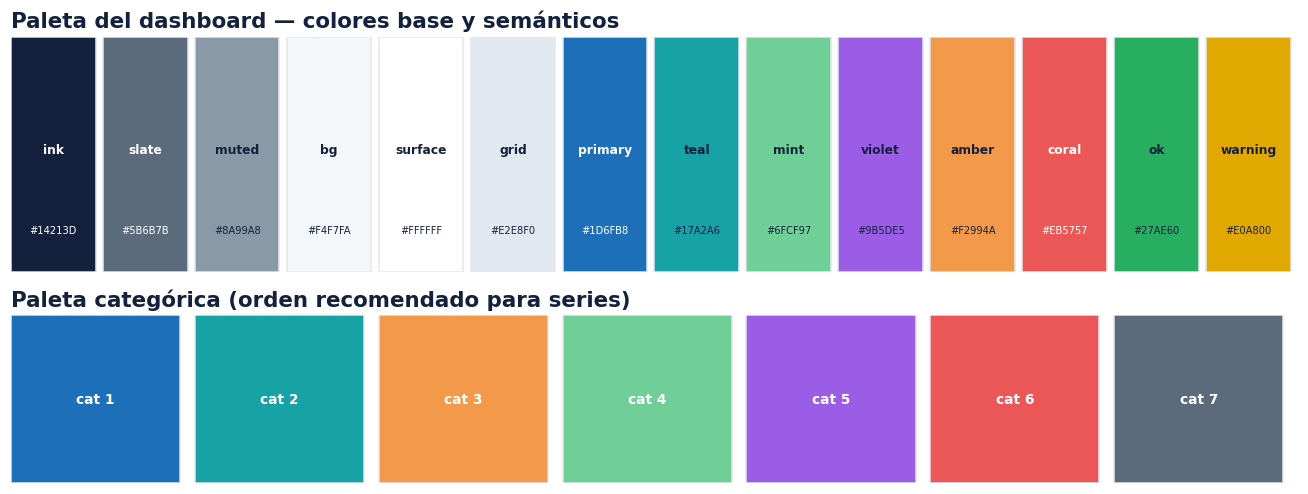

In [ ]:
# ---- Paleta del dashboard --------------------------------------------------
PALETA = {
    'ink':     '#14213D',  # texto principal / títulos
    'slate':   '#5B6B7B',  # texto secundario / ejes
    'muted':   '#8A99A8',  # texto terciario / anotaciones
    'bg':      '#F4F7FA',  # fondo general del dashboard
    'surface': '#FFFFFF',  # tarjetas y áreas de gráfico
    'grid':    '#E2E8F0',  # líneas de cuadrícula
    'primary': '#1D6FB8',  # azul de marca (color principal)
    'teal':    '#17A2A6',  # verde-azulado (secundario)
    'mint':    '#6FCF97',  # verde menta
    'violet':  '#9B5DE5',  # violeta (4ta categoría)
    'amber':   '#F2994A',  # acento cálido -> destacar KPI clave
    'coral':   '#EB5757',  # alerta / valores críticos
    'ok':      '#27AE60',  # semántico: positivo
    'warning': '#E0A800',  # semántico: atención
}

# Paleta categórica ordenada por contraste (apta para comparaciones lado a lado)
CATEGORICAL = [PALETA['primary'], PALETA['teal'], PALETA['amber'],
               PALETA['mint'], PALETA['violet'], PALETA['coral'], PALETA['slate']]

# Escala secuencial (para heatmaps / intensidad)
CMAP_SEC = LinearSegmentedColormap.from_list(
    'covid_seq', ['#EAF2F9', '#A9CCE8', '#5B9BD5', PALETA['primary'], PALETA['ink']]
)

# ---- Aplicar la identidad a Matplotlib ------------------------------------
mpl.rcParams.update({
    'figure.facecolor':  PALETA['surface'],
    'axes.facecolor':    PALETA['surface'],
    'savefig.facecolor': PALETA['surface'],
    'axes.edgecolor':    PALETA['grid'],
    'axes.linewidth':    1.0,
    'axes.grid':         True,
    'grid.color':        PALETA['grid'],
    'grid.linewidth':    0.9,
    'axes.axisbelow':    True,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlecolor':   PALETA['ink'],
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelcolor':   PALETA['slate'],
    'text.color':        PALETA['ink'],
    'xtick.color':       PALETA['slate'],
    'ytick.color':       PALETA['slate'],
    'axes.prop_cycle':   cycler(color=CATEGORICAL),
    # Tipografía: pila web -> con fallback a fuentes presentes en el sistema
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Inter', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'figure.dpi':        110,
})
sns.set_style('white')

# ---- Visualizar la paleta (muestrario) ------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4.6),
                               gridspec_kw={'height_ratios': [1.4, 1]})

base = ['ink', 'slate', 'muted', 'bg', 'surface', 'grid',
        'primary', 'teal', 'mint', 'violet', 'amber', 'coral', 'ok', 'warning']
for i, name in enumerate(base):
    ax1.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=PALETA[name],
                                ec=PALETA['grid']))
    txt_color = PALETA['surface'] if name in ('ink', 'slate', 'primary', 'coral') else PALETA['ink']
    ax1.text(i + 0.46, 0.52, name, ha='center', va='center',
             fontsize=8, color=txt_color, fontweight='bold')
    ax1.text(i + 0.46, 0.18, PALETA[name], ha='center', va='center',
             fontsize=6.5, color=txt_color)
ax1.set_xlim(0, len(base)); ax1.set_ylim(0, 1); ax1.axis('off')
ax1.set_title('Paleta del dashboard — colores base y semánticos', loc='left')

for i, c in enumerate(CATEGORICAL):
    ax2.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=c, ec=PALETA['grid']))
    ax2.text(i + 0.46, 0.5, f'cat {i+1}', ha='center', va='center',
             fontsize=9, color=PALETA['surface'], fontweight='bold')
ax2.set_xlim(0, len(CATEGORICAL)); ax2.set_ylim(0, 1); ax2.axis('off')
ax2.set_title('Paleta categórica (orden recomendado para series)', loc='left')

plt.tight_layout(); plt.show()

> **Justificación de la paleta:**
> - **Azul (`primary`) + teal (`teal`)** como base: el campo es salud/ciencia; estos tonos comunican confianza y neutralidad, evitando el rojo de "emergencia" que sesgaría la lectura de un dashboard analítico.
> - **Ámbar (`amber`) como único acento cálido:** se reserva para *resaltar el KPI o la categoría más relevante*. Al ser el único color cálido entre fríos, la atención va justo a donde queremos.
> - **Coral/rojo (`coral`) solo para alertas:** no se usa como color decorativo, así conserva su significado.
> - **Accesibilidad:** los colores categóricos se ordenaron alternando tono y luminosidad para que sigan siendo distinguibles; el texto fuerte (`ink #14213D`) sobre fondo (`surface #FFFFFF`) supera holgadamente el contraste AA (>7:1).

## 2.2 Tipografía

Un dashboard de este corpus mostrará **muchos KPIs numéricos** (conteos, porcentajes, medianas), **etiquetas categóricas largas** (nombres de revistas) y **textos densos**. La tipografía debe priorizar **legibilidad a tamaño pequeño** y **números bien alineados**. Proponemos una jerarquía de tres familias (todas open-source, vía Google Fonts):

- **Títulos / encabezados → `Poppins`** (geométrica, moderna, con autoridad amable).
- **Cuerpo, ejes y etiquetas → `Inter`** (diseñada para interfaces; excelente legibilidad a 12–14 px).
- **Números / KPIs → `JetBrains Mono`** (monoespaciada con *tabular figures*: las cifras quedan alineadas en columnas y tarjetas).

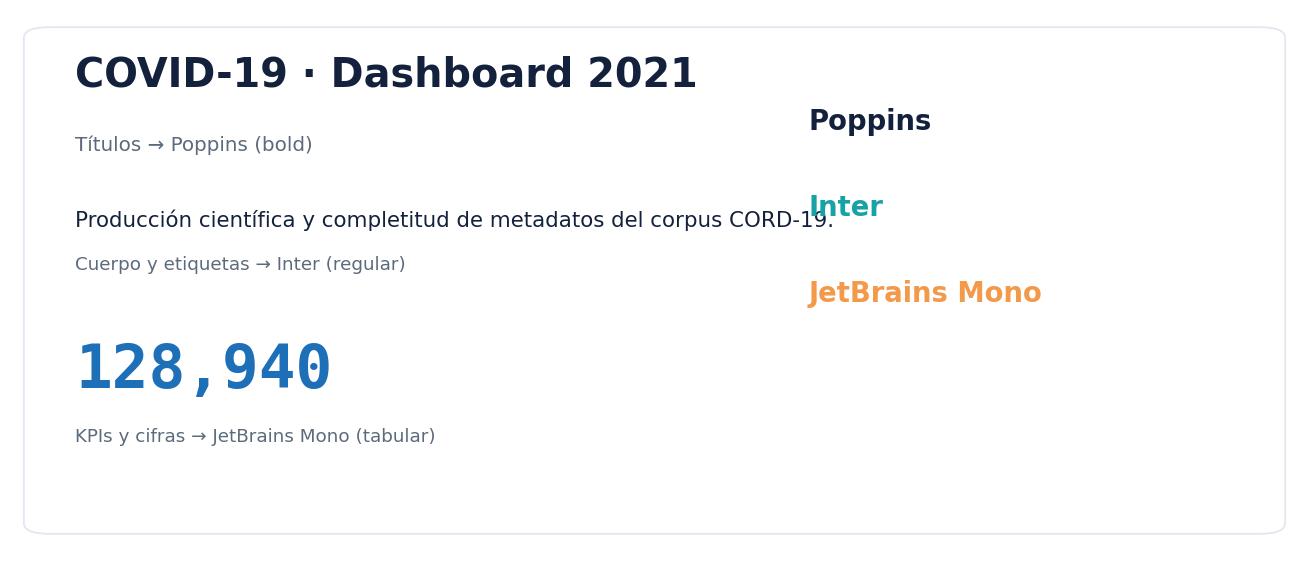

Pilas tipográficas del dashboard:
  titulos : 'Poppins', 'Segoe UI', Helvetica, Arial, sans-serif
  cuerpo  : 'Inter', 'Helvetica Neue', Arial, sans-serif
  numeros : 'JetBrains Mono', 'Roboto Mono', ui-monospace, monospace


In [ ]:
# Pilas tipográficas (CSS) que usará el dashboard, con fallbacks seguros
FONT_STACKS = {
    'titulos': "'Poppins', 'Segoe UI', Helvetica, Arial, sans-serif",
    'cuerpo':  "'Inter', 'Helvetica Neue', Arial, sans-serif",
    'numeros': "'JetBrains Mono', 'Roboto Mono', ui-monospace, monospace",
}
ESCALA_TIPO = {  # escala tipográfica (px) sugerida para el dashboard
    'display': 34, 'h1': 26, 'h2': 20, 'h3': 16,
    'cuerpo': 14, 'etiqueta': 12, 'kpi': 40,
}

# Vista previa de la jerarquía (Matplotlib usa fallback si las fuentes no están instaladas)
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axis('off')
ax.add_patch(FancyBboxPatch((0.02, 0.04), 0.96, 0.92,
             boxstyle='round,pad=0.01,rounding_size=0.02',
             fc=PALETA['surface'], ec=PALETA['grid'], lw=1.2,
             transform=ax.transAxes))

ax.text(0.05, 0.86, 'COVID-19 · Dashboard 2021', transform=ax.transAxes,
        fontsize=26, fontweight='bold', color=PALETA['ink'])
ax.text(0.05, 0.74, 'Títulos → Poppins (bold)', transform=ax.transAxes,
        fontsize=13, color=PALETA['slate'])

ax.text(0.05, 0.60, 'Producción científica y completitud de metadatos del corpus CORD-19.',
        transform=ax.transAxes, fontsize=14, color=PALETA['ink'])
ax.text(0.05, 0.52, 'Cuerpo y etiquetas → Inter (regular)', transform=ax.transAxes,
        fontsize=12, color=PALETA['slate'])

ax.text(0.05, 0.30, '128,940', transform=ax.transAxes, family='monospace',
        fontsize=40, fontweight='bold', color=PALETA['primary'])
ax.text(0.05, 0.20, 'KPIs y cifras → JetBrains Mono (tabular)', transform=ax.transAxes,
        fontsize=12, color=PALETA['slate'])

for i, (lab, c) in enumerate([('Poppins', PALETA['ink']), ('Inter', PALETA['teal']),
                              ('JetBrains Mono', PALETA['amber'])]):
    ax.text(0.62, 0.78 - i*0.16, lab, transform=ax.transAxes, fontsize=18,
            fontweight='bold', color=c)
plt.tight_layout(); plt.show()

print('Pilas tipográficas del dashboard:')
for k, v in FONT_STACKS.items():
    print(f'  {k:8s}: {v}')

> **Justificación de la tipografía:**
> - **`Inter` para el cuerpo:** está optimizada para pantallas y mantiene legibilidad en etiquetas pequeñas (12 px), justo donde un dashboard sufre más (nombres de revistas, leyendas, ejes).
> - **`JetBrains Mono` para cifras:** sus *tabular figures* hacen que los números de las tarjetas KPI y las tablas queden alineados verticalmente, facilitando comparar magnitudes de un vistazo.
> - **`Poppins` para títulos:** su forma geométrica aporta jerarquía y un tono moderno sin restar seriedad, contrastando con `Inter` para separar claramente "título" de "contenido".
> - Las tres son **gratuitas y de uso libre (Google Fonts / OFL)**, lo que simplifica el despliegue del dashboard.

---

# 3. Análisis Exploratorio de Datos (EDA) — corpus 2021

## 3.1 Estructura general

Tipos de datos del subconjunto, vista rápida y resumen estadístico de las variables numéricas derivadas.

In [ ]:
print('Dimensiones:', df_eda.shape)
print('\nTipos de datos:')
print(df_eda.dtypes)
print('\nResumen estadístico (variables numéricas):')
df_eda[['title_len', 'abstract_len', 'n_authors']].describe().round(1)

Dimensiones: (158278, 12)

Tipos de datos:
cord_uid          object
source_x          object
journal           object
license           object
publish_month    float64
title_len        float64
abstract_len     float64
n_authors          int32
has_abstract       int32
has_doi            int32
has_pmcid          int32
has_journal        int32
dtype: object

Resumen estadístico (variables numéricas):


,title_len,abstract_len,n_authors
count,158212.0,122350.0,158278.0
mean,100.3,1483.3,6.2
std,39.7,617.9,19.8
min,4.0,1.0,0.0
25%,73.0,1089.0,2.0
50%,97.0,1469.0,4.0
75%,123.0,1804.0,8.0
max,1504.0,14900.0,6337.0


## 3.2 Completitud de los datos (valores nulos)

Para un dashboard es clave saber qué campos están disponibles. Calculamos el % de nulos por columna sobre **todas las columnas originales** del corpus 2021 (en Spark) y lo visualizamos.

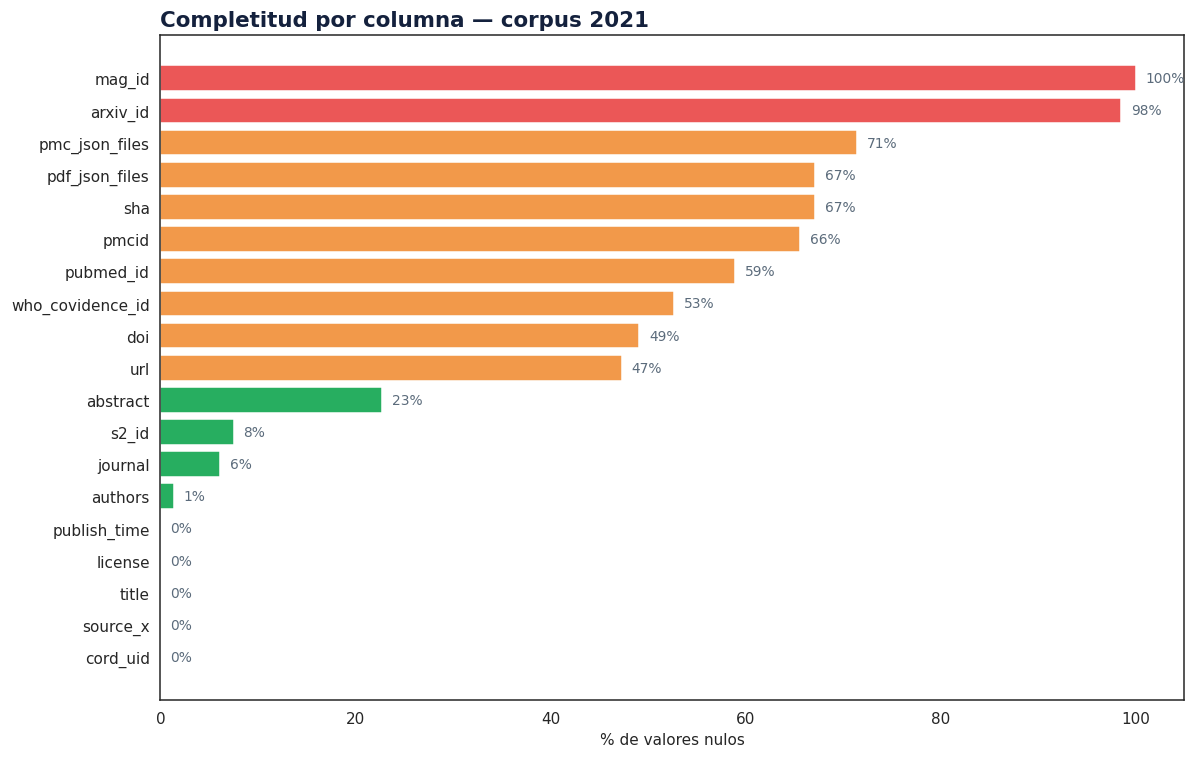

In [ ]:
ORIG_COLS = ['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id',
             'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id',
             'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']

nulos = (
    df_2021.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in ORIG_COLS])
           .toPandas().T.rename(columns={0: 'n_nulos'})
)
nulos['pct_nulos'] = (nulos['n_nulos'] / n_2021 * 100).round(1)
nulos = nulos.sort_values('pct_nulos', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
# Color en función de la severidad: ok -> amber -> coral
def color_pct(p):
    return PALETA['ok'] if p < 25 else (PALETA['amber'] if p < 75 else PALETA['coral'])
colors = [color_pct(p) for p in nulos['pct_nulos']]
ax.barh(nulos.index, nulos['pct_nulos'], color=colors, edgecolor='white')
for y, p in enumerate(nulos['pct_nulos']):
    ax.text(p + 1, y, f'{p:.0f}%', va='center', fontsize=9, color=PALETA['slate'])
ax.set_xlim(0, 105)
ax.set_xlabel('% de valores nulos')
ax.set_title('Completitud por columna — corpus 2021', loc='left')
plt.tight_layout(); plt.show()

> **Conclusión 3.2:** Campos como `mag_id`, `who_covidence_id` y `arxiv_id` están casi siempre vacíos → **no deberían ir al dashboard**. En cambio `title`, `source_x`, `authors`, `publish_time` y, en buena medida, `abstract` y `journal` tienen completitud suficiente para construir métricas fiables.

## 3.3 Evolución temporal: publicaciones por mes (2021)

Una serie temporal es casi obligatoria en el dashboard. Vemos el volumen mensual y el acumulado.

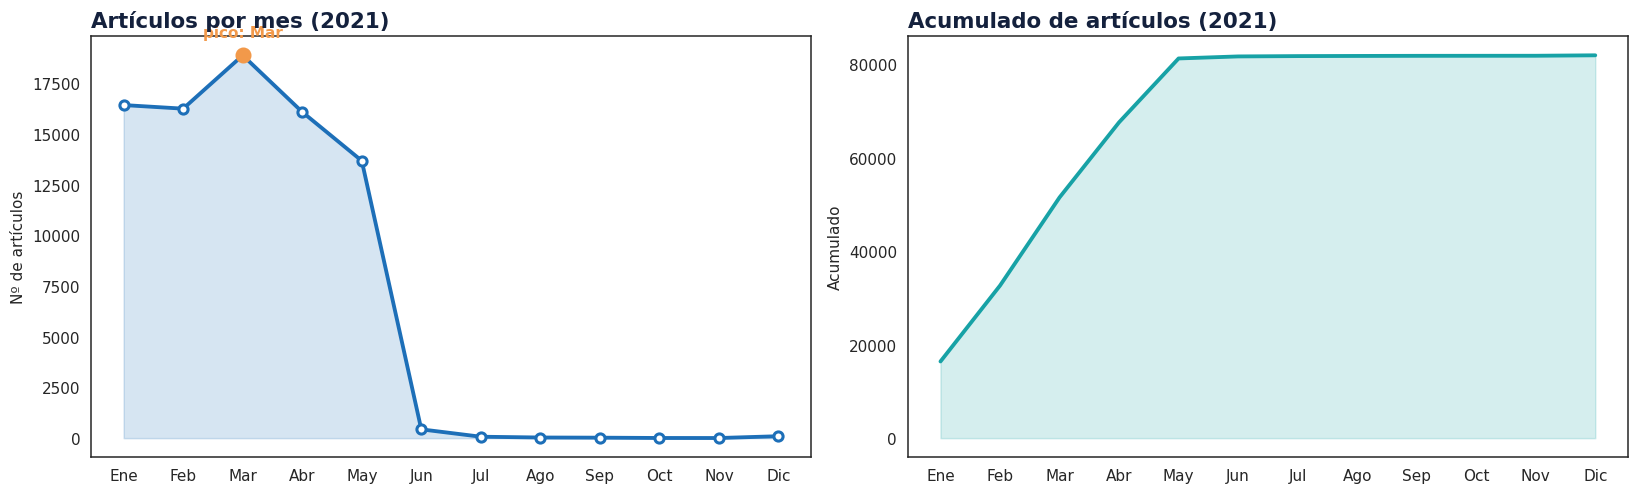

publish_month     1      2      3      4      5    6   7   8   9   10  11  12
n_articulos    16415  16238  18867  16074  13669  434  71  32  24   9   7  96


In [ ]:
por_mes = (
    df_eda[df_eda['publish_month'].notna()]
    .groupby('publish_month').size().reindex(range(1, 13), fill_value=0)
)
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))

ax1.fill_between(range(12), por_mes.values, color=PALETA['primary'], alpha=0.18)
ax1.plot(range(12), por_mes.values, color=PALETA['primary'], lw=2.5, marker='o',
         markerfacecolor=PALETA['surface'], markeredgewidth=2)
pico = int(np.argmax(por_mes.values))
ax1.scatter([pico], [por_mes.values[pico]], color=PALETA['amber'], zorder=5, s=90)
ax1.annotate(f'pico: {meses[pico]}', (pico, por_mes.values[pico]),
             textcoords='offset points', xytext=(0, 12), ha='center',
             color=PALETA['amber'], fontweight='bold')
ax1.set_xticks(range(12)); ax1.set_xticklabels(meses)
ax1.set_title('Artículos por mes (2021)', loc='left')
ax1.set_ylabel('Nº de artículos')

ax2.fill_between(range(12), por_mes.cumsum().values, color=PALETA['teal'], alpha=0.18)
ax2.plot(range(12), por_mes.cumsum().values, color=PALETA['teal'], lw=2.5)
ax2.set_xticks(range(12)); ax2.set_xticklabels(meses)
ax2.set_title('Acumulado de artículos (2021)', loc='left')
ax2.set_ylabel('Acumulado')

plt.tight_layout(); plt.show()
print(por_mes.to_frame('n_articulos').T)

> **Conclusión 3.3:** El volumen de publicación se mantiene alto durante todo 2021. Esta serie es buena candidata a **gráfico principal** del dashboard (línea/área con el mes pico resaltado en ámbar).

## 3.4 Variables categóricas: fuentes, revistas y licencias

Las tres categóricas más útiles para el dashboard. Usamos la paleta categórica y resaltamos en ámbar el líder de cada ranking.

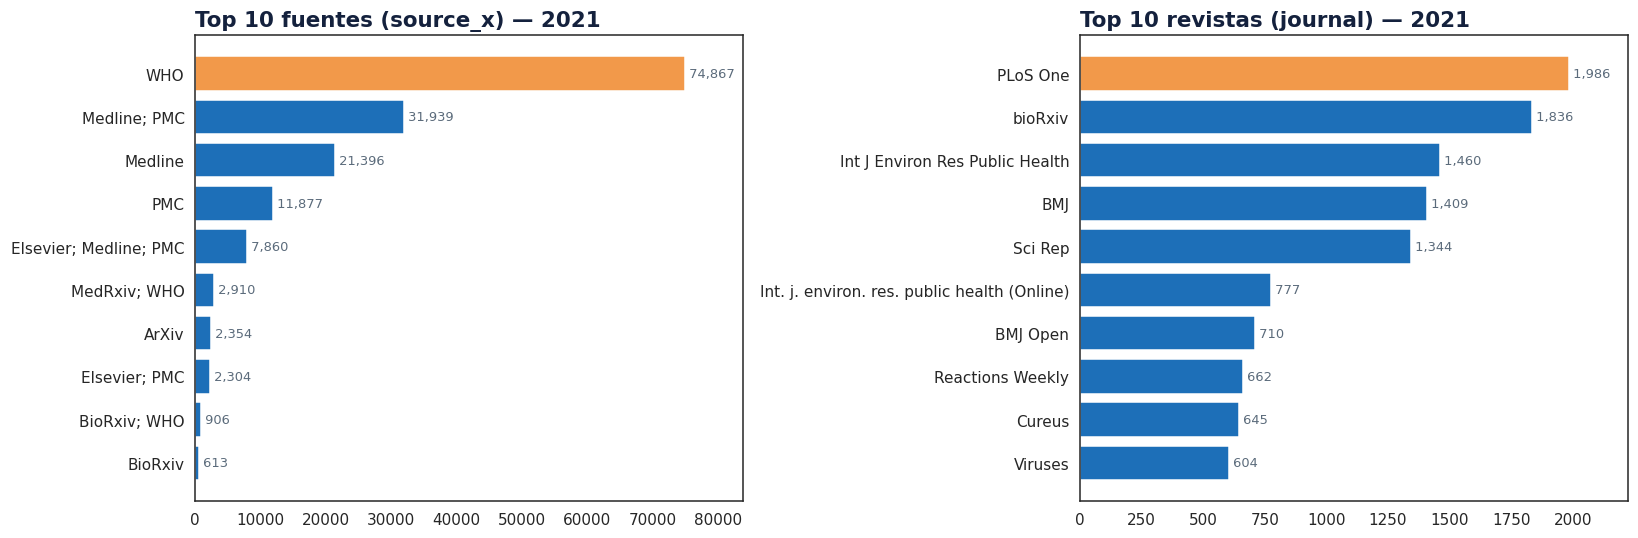

In [ ]:
def barh_top(serie, titulo, ax, n=10):
    top = serie.value_counts().head(n).iloc[::-1]
    colors = [PALETA['primary']] * len(top)
    colors[-1] = PALETA['amber']  # el de mayor frecuencia queda resaltado
    ax.barh(top.index.astype(str), top.values, color=colors, edgecolor='white')
    for y, v in enumerate(top.values):
        ax.text(v, y, f' {v:,}', va='center', fontsize=8.5, color=PALETA['slate'])
    ax.set_title(titulo, loc='left')
    ax.margins(x=0.12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
barh_top(df_eda['source_x'], 'Top 10 fuentes (source_x) — 2021', axes[0])
barh_top(df_eda['journal'].dropna(), 'Top 10 revistas (journal) — 2021', axes[1])
plt.tight_layout(); plt.show()

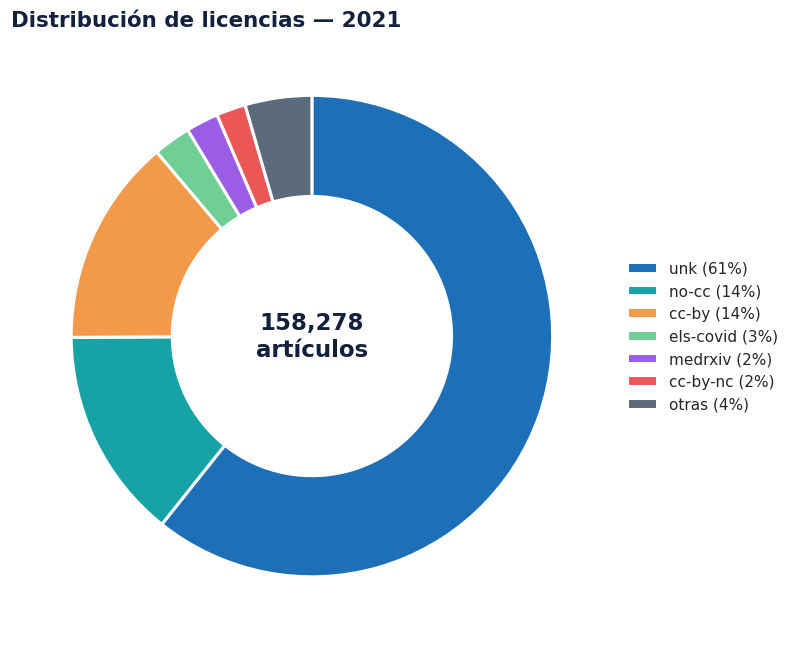

In [ ]:
# Distribución de licencias (las 6 principales + 'otras') como dona
lic = df_eda['license'].fillna('desconocida').value_counts()
top_lic = lic.head(6)
otras = lic.iloc[6:].sum()
if otras > 0:
    top_lic = pd.concat([top_lic, pd.Series({'otras': otras})])

fig, ax = plt.subplots(figsize=(7.5, 6))
wedges, _ = ax.pie(top_lic.values, startangle=90, counterclock=False,
                   colors=CATEGORICAL[:len(top_lic)],
                   wedgeprops=dict(width=0.42, edgecolor=PALETA['surface'], linewidth=2))
ax.text(0, 0, f"{len(df_eda):,}\nartículos", ha='center', va='center',
        fontsize=15, fontweight='bold', color=PALETA['ink'])
ax.legend(wedges, [f'{k} ({v/len(df_eda)*100:.0f}%)' for k, v in top_lic.items()],
          loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.set_title('Distribución de licencias — 2021', loc='left')
plt.tight_layout(); plt.show()

> **Conclusión 3.4:** Dominan fuentes biomédicas (PubMed/Medline, PMC) y revistas como PLoS One, Sci Rep, etc.; la mayoría del corpus es de **acceso abierto** (`cc-by` y derivadas). En el dashboard estas categóricas funcionan bien como **rankings horizontales** (nombres largos legibles) con el líder en ámbar.

## 3.5 Variables numéricas: longitud de título y abstract

Distribución de longitudes (con *boxplot* para ver outliers). Acotamos visualmente los valores extremos para legibilidad.

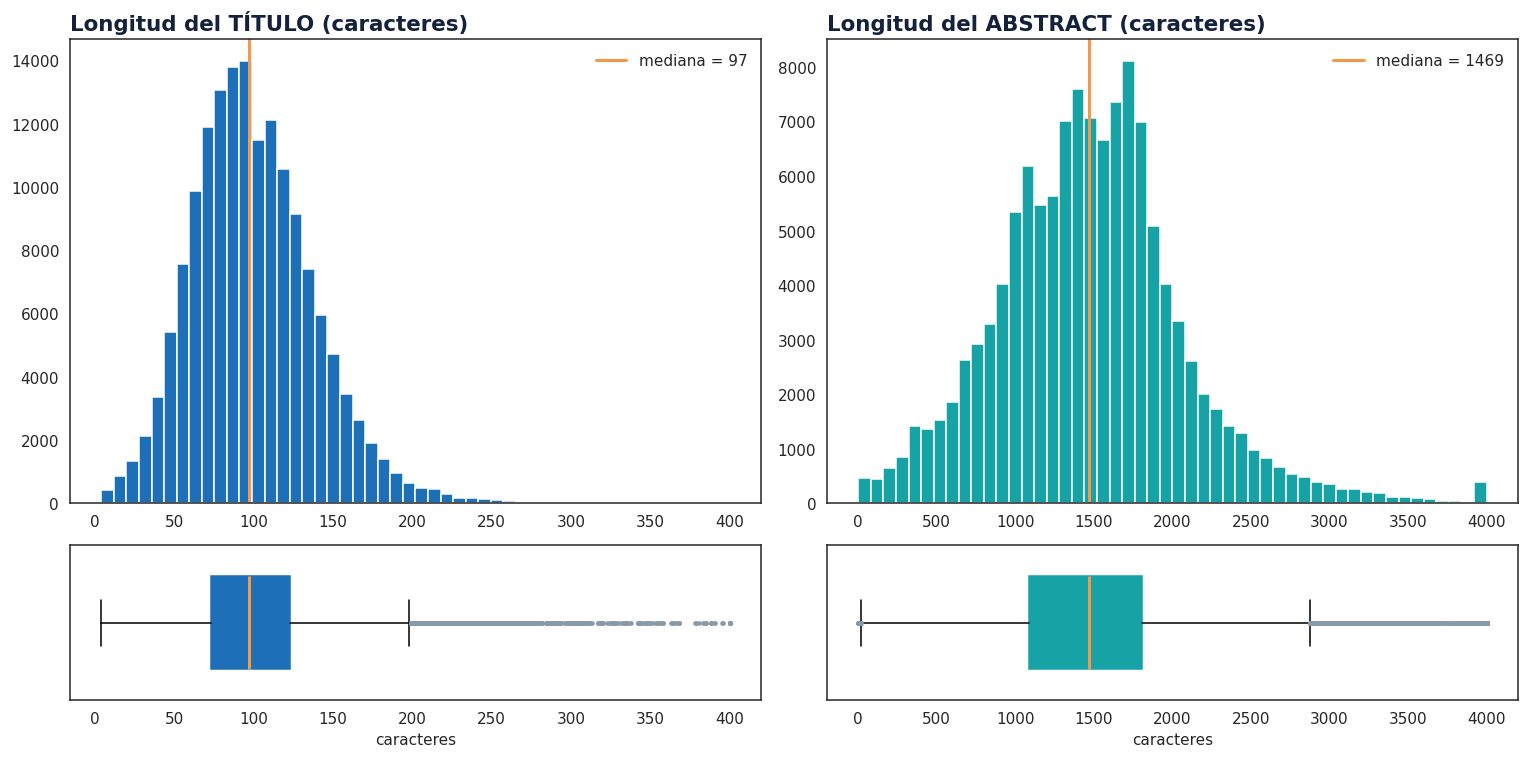

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7),
                         gridspec_kw={'height_ratios': [3, 1]})

# Título
t = df_eda['title_len'].dropna().clip(upper=400)
axes[0, 0].hist(t, bins=50, color=PALETA['primary'], edgecolor='white')
axes[0, 0].axvline(t.median(), color=PALETA['amber'], lw=2,
                   label=f'mediana = {t.median():.0f}')
axes[0, 0].legend(frameon=False); axes[0, 0].set_title('Longitud del TÍTULO (caracteres)', loc='left')
axes[1, 0].boxplot(t, vert=False, widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=PALETA['primary'], color=PALETA['primary']),
                   medianprops=dict(color=PALETA['amber'], linewidth=2),
                   flierprops=dict(marker='o', markersize=3, markerfacecolor=PALETA['muted'], markeredgecolor='none'))
axes[1, 0].set_yticks([]); axes[1, 0].set_xlabel('caracteres')

# Abstract
a = df_eda['abstract_len'].dropna().clip(upper=4000)
axes[0, 1].hist(a, bins=50, color=PALETA['teal'], edgecolor='white')
axes[0, 1].axvline(a.median(), color=PALETA['amber'], lw=2,
                   label=f'mediana = {a.median():.0f}')
axes[0, 1].legend(frameon=False); axes[0, 1].set_title('Longitud del ABSTRACT (caracteres)', loc='left')
axes[1, 1].boxplot(a, vert=False, widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=PALETA['teal'], color=PALETA['teal']),
                   medianprops=dict(color=PALETA['amber'], linewidth=2),
                   flierprops=dict(marker='o', markersize=3, markerfacecolor=PALETA['muted'], markeredgecolor='none'))
axes[1, 1].set_yticks([]); axes[1, 1].set_xlabel('caracteres')

plt.tight_layout(); plt.show()

## 3.6 Número de autores por artículo

La colaboración científica es una métrica interesante. Vemos la distribución y los percentiles.

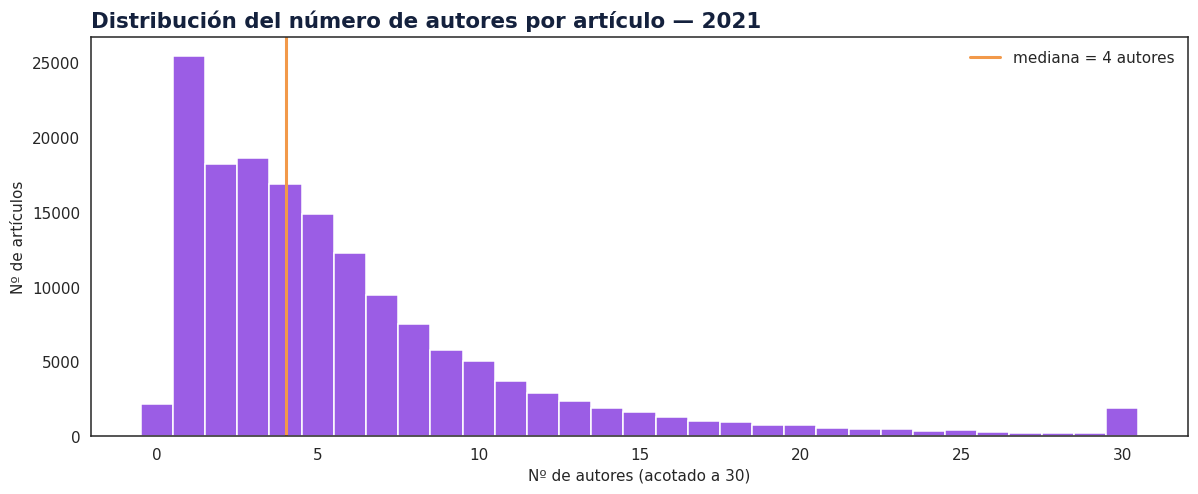

Percentiles del nº de autores:
count    158278.0
mean          6.2
std          19.8
min           0.0
25%           2.0
50%           4.0
75%           8.0
90%          12.0
99%          32.0
max        6337.0
Name: n_authors, dtype: float64


In [ ]:
na = df_eda['n_authors'].clip(upper=30)
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.hist(na, bins=range(0, 32), color=PALETA['violet'], edgecolor='white', align='left')
med = df_eda['n_authors'].median()
ax.axvline(med, color=PALETA['amber'], lw=2, label=f'mediana = {med:.0f} autores')
ax.set_xlabel('Nº de autores (acotado a 30)'); ax.set_ylabel('Nº de artículos')
ax.set_title('Distribución del número de autores por artículo — 2021', loc='left')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print('Percentiles del nº de autores:')
print(df_eda['n_authors'].describe(percentiles=[.25, .5, .75, .9, .99]).round(1))

> **Conclusión 3.5–3.6:** Los títulos rondan ~80–150 caracteres y los abstracts ~1.200–2.000; ambas variables tienen outliers extremos (textos larguísimos) que conviene acotar en las visualizaciones. La colaboración típica es de varios autores por artículo, con una cola larga de trabajos muy multitudinarios. Como KPIs del dashboard usaremos **medianas** (robustas a outliers), no medias.

## 3.7 Relaciones entre variables

Matriz de correlación de las numéricas y relación entre longitud del abstract y número de autores.

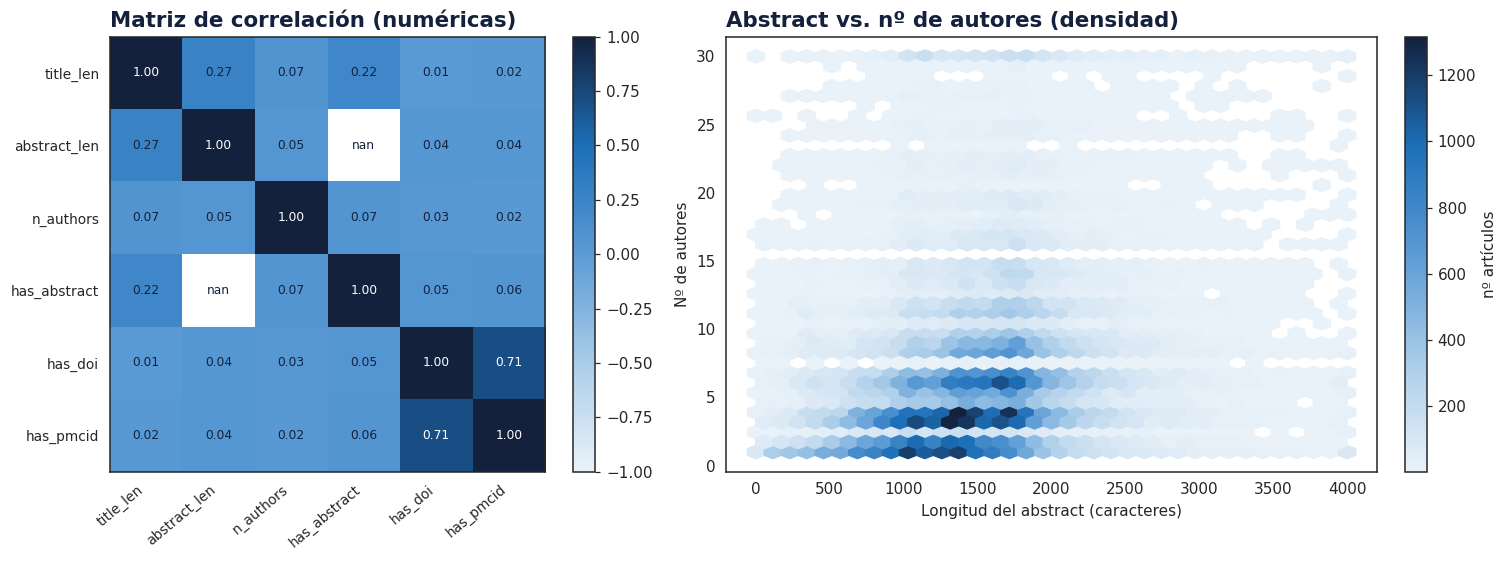

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# Matriz de correlación
corr = df_eda[['title_len', 'abstract_len', 'n_authors',
               'has_abstract', 'has_doi', 'has_pmcid']].corr()
im = axes[0].imshow(corr, cmap=CMAP_SEC, vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr))); axes[0].set_yticks(range(len(corr)))
axes[0].set_xticklabels(corr.columns, rotation=40, ha='right', fontsize=9)
axes[0].set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=8, color=PALETA['surface'] if abs(val) > 0.5 else PALETA['ink'])
axes[0].grid(False)
axes[0].set_title('Matriz de correlación (numéricas)', loc='left')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Relación abstract_len vs n_authors (hexbin para densidad)
sub = df_eda[(df_eda['abstract_len'].notna()) & (df_eda['n_authors'] > 0)]
hb = axes[1].hexbin(sub['abstract_len'].clip(upper=4000),
                    sub['n_authors'].clip(upper=30),
                    gridsize=35, cmap=CMAP_SEC, mincnt=1)
axes[1].set_xlabel('Longitud del abstract (caracteres)')
axes[1].set_ylabel('Nº de autores')
axes[1].set_title('Abstract vs. nº de autores (densidad)', loc='left')
axes[1].grid(False)
fig.colorbar(hb, ax=axes[1], fraction=0.046, pad=0.04, label='nº artículos')

plt.tight_layout(); plt.show()

> **Conclusión 3.7:** Las correlaciones entre las variables numéricas son débiles (los metadatos son bastante independientes entre sí), lo que sugiere que en el dashboard conviene mostrarlas como **indicadores separados** en lugar de buscar relaciones lineales fuertes. El hexbin confirma que no hay una dependencia clara entre extensión del abstract y tamaño del equipo de autores.

> **Conclusiones generales del EDA (2021):**
> - El corpus 2021 es **voluminoso y de producción sostenida** todo el año → la serie temporal es el eje narrativo del dashboard.
> - Hay **campos muy incompletos** (descartables) y **campos sólidos** (fuentes, revistas, licencias, longitudes, autores) sobre los que construir métricas.
> - Las distribuciones tienen **outliers**, por lo que los KPIs se basarán en **medianas**.
> - El dominio es **biomédico y de acceso abierto**, lo que respalda la identidad visual elegida (azules/teal de confianza, ámbar para destacar).

---

# 4. Síntesis: del EDA al diseño del dashboard

Reunimos lo aprendido en una **maqueta de baja fidelidad** del dashboard, construida solo con Matplotlib y aplicando la paleta y la tipografía definidas. Muestra el patrón propuesto: una fila de **tarjetas KPI** (cifras en monoespaciada) sobre fondo `bg`, más dos gráficos clave (serie temporal y ranking de fuentes).

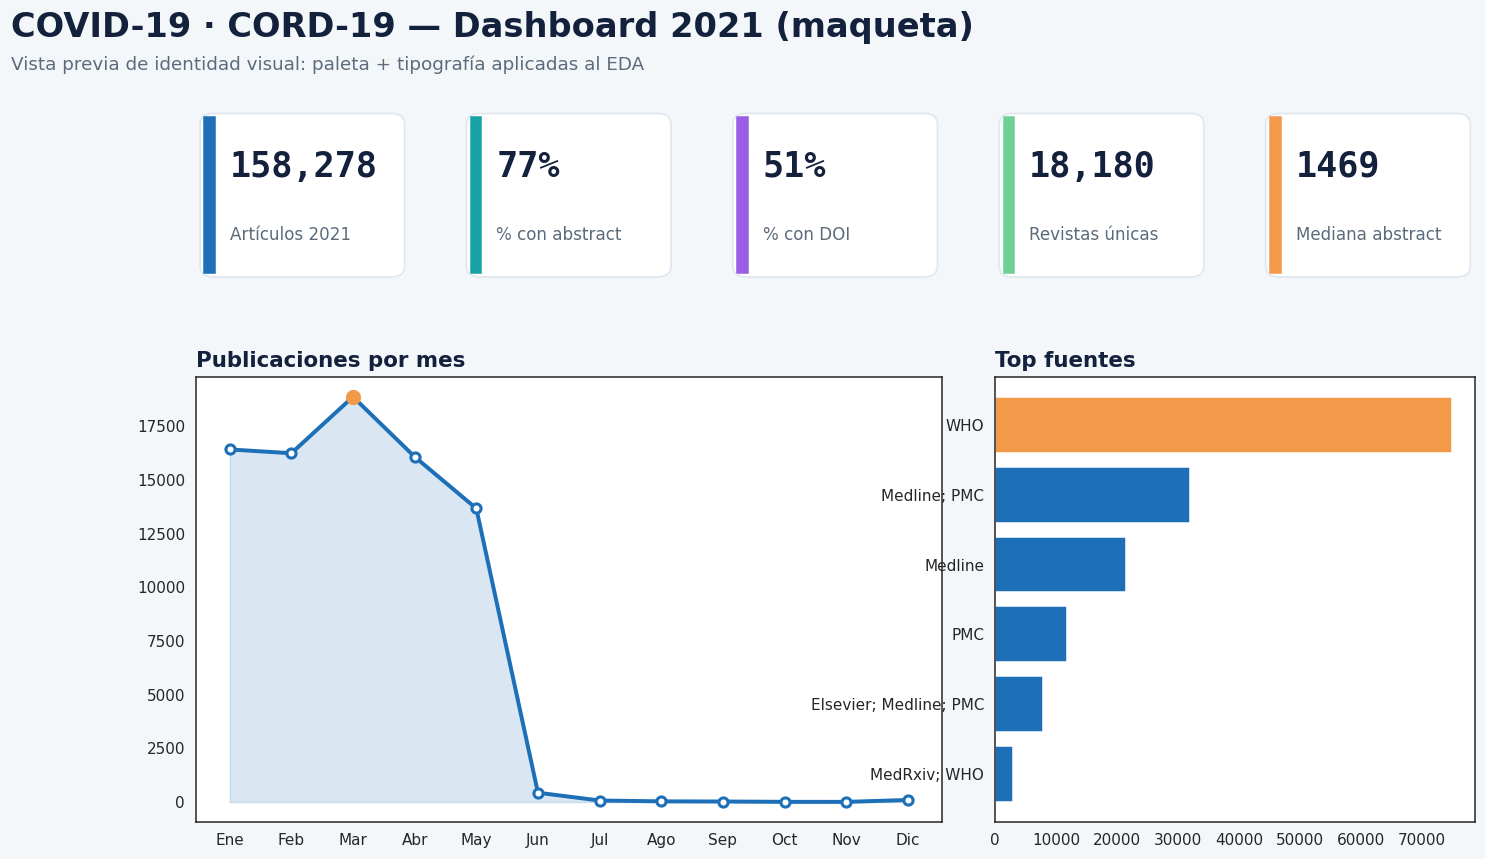

In [ ]:
# --- KPIs derivados del EDA ---
kpis = [
    ('Artículos 2021', f"{len(df_eda):,}",                              PALETA['primary']),
    ('% con abstract', f"{df_eda['has_abstract'].mean()*100:.0f}%",     PALETA['teal']),
    ('% con DOI',      f"{df_eda['has_doi'].mean()*100:.0f}%",          PALETA['violet']),
    ('Revistas únicas', f"{df_eda['journal'].nunique():,}",             PALETA['mint']),
    ('Mediana abstract', f"{int(df_eda['abstract_len'].median())}",     PALETA['amber']),
]

fig = plt.figure(figsize=(15, 8.5))
fig.patch.set_facecolor(PALETA['bg'])
gs = fig.add_gridspec(2, 5, height_ratios=[1, 2.4], hspace=0.28, wspace=0.25)

# Banda de título
fig.text(0.013, 0.95, 'COVID-19 · CORD-19 — Dashboard 2021 (maqueta)',
         fontsize=22, fontweight='bold', color=PALETA['ink'])
fig.text(0.013, 0.915, 'Vista previa de identidad visual: paleta + tipografía aplicadas al EDA',
         fontsize=12, color=PALETA['slate'])

# Tarjetas KPI
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.04, 0.08), 0.92, 0.84,
                 boxstyle='round,pad=0.02,rounding_size=0.06',
                 fc=PALETA['surface'], ec=PALETA['grid'], lw=1.2,
                 transform=ax.transAxes))
    ax.add_patch(plt.Rectangle((0.04, 0.08), 0.05, 0.84, color=color,
                 transform=ax.transAxes))  # franja de acento
    ax.text(0.16, 0.60, value, transform=ax.transAxes, family='monospace',
            fontsize=23, fontweight='bold', color=PALETA['ink'])
    ax.text(0.16, 0.26, label, transform=ax.transAxes, fontsize=11, color=PALETA['slate'])

# Gráfico 1: serie temporal
ax1 = fig.add_subplot(gs[1, 0:3])
ax1.set_facecolor(PALETA['surface'])
ax1.fill_between(range(12), por_mes.values, color=PALETA['primary'], alpha=0.16)
ax1.plot(range(12), por_mes.values, color=PALETA['primary'], lw=2.6, marker='o',
         markerfacecolor=PALETA['surface'], markeredgewidth=2)
ax1.scatter([pico], [por_mes.values[pico]], color=PALETA['amber'], zorder=5, s=80)
ax1.set_xticks(range(12)); ax1.set_xticklabels(meses)
ax1.set_title('Publicaciones por mes', loc='left')

# Gráfico 2: ranking de fuentes
ax2 = fig.add_subplot(gs[1, 3:5])
ax2.set_facecolor(PALETA['surface'])
top = df_eda['source_x'].value_counts().head(6).iloc[::-1]
cols = [PALETA['primary']] * len(top); cols[-1] = PALETA['amber']
ax2.barh(top.index.astype(str), top.values, color=cols, edgecolor='white')
ax2.set_title('Top fuentes', loc='left')

plt.show()

## 4.1 Mapa de uso (cómo se aplica la identidad)

| Elemento del dashboard | Color | Tipografía |
|---|---|---|
| Título / encabezados | `ink` (#14213D) | Poppins **bold** |
| Texto, ejes, leyendas | `slate` (#5B6B7B) | Inter regular |
| Cifras de tarjetas KPI | `ink` / acento | JetBrains Mono **bold** |
| Series y barras (principal) | `primary` (#1D6FB8) | — |
| Segunda serie / comparación | `teal` (#17A2A6) | — |
| Dato/categoría a destacar | `amber` (#F2994A) | — |
| Alertas y valores críticos | `coral` (#EB5757) | — |
| Heatmaps / intensidad | escala `CMAP_SEC` (azules) | — |
| Fondo general / tarjetas | `bg` / `surface` | — |

## 4.2 Exportar los *design tokens*

Guardamos la paleta y la tipografía en `design_tokens.json` para que el equipo que construya el dashboard (web, Power BI, etc.) reutilice exactamente los mismos valores.

In [ ]:
design_tokens = {
    'meta': {'proyecto': 'CORD-19 Dashboard', 'anio_datos': 2021,
             'fase': 'IV - EDA y diseño visual'},
    'colores': PALETA,
    'paleta_categorica': CATEGORICAL,
    'tipografia': {
        'familias': {'titulos': 'Poppins', 'cuerpo': 'Inter', 'numeros': 'JetBrains Mono'},
        'font_stacks_css': FONT_STACKS,
        'escala_px': ESCALA_TIPO,
    },
}

with open('design_tokens.json', 'w') as f:
    json.dump(design_tokens, f, ensure_ascii=False, indent=2)

print('design_tokens.json guardado.\n')
print(json.dumps(design_tokens, ensure_ascii=False, indent=2))

design_tokens.json guardado.

{
  "meta": {
    "proyecto": "CORD-19 Dashboard",
    "anio_datos": 2021,
    "fase": "IV - EDA y diseño visual"
  },
  "colores": {
    "ink": "#14213D",
    "slate": "#5B6B7B",
    "muted": "#8A99A8",
    "bg": "#F4F7FA",
    "surface": "#FFFFFF",
    "grid": "#E2E8F0",
    "primary": "#1D6FB8",
    "teal": "#17A2A6",
    "mint": "#6FCF97",
    "violet": "#9B5DE5",
    "amber": "#F2994A",
    "coral": "#EB5757",
    "ok": "#27AE60",
    "warning": "#E0A800"
  },
  "paleta_categorica": [
    "#1D6FB8",
    "#17A2A6",
    "#F2994A",
    "#6FCF97",
    "#9B5DE5",
    "#EB5757",
    "#5B6B7B"
  ],
  "tipografia": {
    "familias": {
      "titulos": "Poppins",
      "cuerpo": "Inter",
      "numeros": "JetBrains Mono"
    },
    "font_stacks_css": {
      "titulos": "'Poppins', 'Segoe UI', Helvetica, Arial, sans-serif",
      "cuerpo": "'Inter', 'Helvetica Neue', Arial, sans-serif",
      "numeros": "'JetBrains Mono', 'Roboto Mono', ui-monospace, monospace"

> **Conclusión Fase IV:**
> - El EDA del corpus 2021 muestra un dataset voluminoso, de producción sostenida, dominio biomédico y acceso abierto, con varios campos descartables por baja completitud y distribuciones con outliers.
> - A partir de esa lectura definimos una **identidad visual**: paleta de **azules/teal de confianza** con **ámbar** para destacar y **coral** solo para alertas, más una **jerarquía tipográfica** (Poppins / Inter / JetBrains Mono) pensada para KPIs y etiquetas densas.
> - La identidad se aplicó a todas las gráficas y a una **maqueta del dashboard**, y se exportó a `design_tokens.json` para construir el dashboard de forma consistente.

In [ ]:
# Liberamos recursos de Spark al final
spark.stop()
print('SparkSession detenida. Fin del notebook (Fase IV).')

SparkSession detenida. Fin del notebook (Fase IV).
